# Did COVID-19 Change Safe-Haven Behaviour?


**Authors:** Aymen Laraoui
**Date:** May 2026

---

## 0. Imports & Setup

Imports and global configuration.

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'arch', 'ruptures'], capture_output=True)

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import stats
from scipy.stats import jarque_bera, kstest, norm

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from arch import arch_model
import ruptures as rpt

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables',  exist_ok=True)

# Global parameters
COVID_DATE = pd.Timestamp('2020-03-11')  # WHO pandemic declaration
SPLIT_DATE = '2020-03-01'  # provisional pre/post split
DURATION_10Y = 8.5  # modified duration for 10Y bond return proxy
TRIM = 0.15  # Andrews (1993) trimming fraction
SUPF_CV_5PCT = 8.85  # Andrews 5% critical value, k=1 restriction
MIN_SEG_BP = 252  # min segment length (1 trading year)
ROLL_WIN = 252  # rolling window (1 trading year)
PRE_COVID_START = '2010-01-01'  # pre-COVID window start (excludes 2008 GFC)
SAFE_HAVENS = ['Gold', 'US10Y', 'USDCHF', 'USDJPY']
BENCHMARKS = ['SP500', 'Eurostoxx50']


## Data Windows

- **Full sample** (1990–2026): descriptive stats, DCC estimation, structural break tests, ERC.
- **Post-2010 sample** (2010–2026): pre/post COVID comparisons (GARCH, Markov switching, Wald tests). The 2010 cutoff excludes the GFC.
- **Pre/post split date**: 2020-03-01.

---

# 1. Data & Stylized Facts

## Step 1.1: Data Loading & Sign Conventions

Six assets from `data/Data.xlsx`. Returns are scaled to percentage points.

| Asset | Transformation |
|---|---|
| S&P 500, Eurostoxx 50, Gold | $\ln(P_t / P_{t-1})$ |
| US 10Y yield | $-\Delta y_t \times D_{\text{mod}} / 100$ (positive = bond price rises) |
| USDCHF, USDJPY | $-\ln(P_t / P_{t-1})$ (foreign currency appreciation as positive) |

The pre/post split date (2020-03-01) is later confirmed endogenously by Bai-Perron.

In [2]:
COLS = {
    'S&P500':             'SP500',
    'Eurostoxx 50':       'Eurostoxx50',
    'Gold':               'Gold',
    'US T 10-year Yield': 'US10Y_yield',   # raw yield level
    'USDCHF':             'USDCHF',
    'USDJPY':             'USDJPY',
}

raw = (pd.read_excel(Path("data/Data.xlsx"), index_col=0, parse_dates=True)
         [list(COLS.keys())]
         .rename(columns=COLS))

returns = pd.DataFrame(index=raw.index)
returns['SP500'] = np.log(raw['SP500'] / raw['SP500'].shift(1))
returns['Eurostoxx50'] = np.log(raw['Eurostoxx50'] / raw['Eurostoxx50'].shift(1))
returns['Gold'] = np.log(raw['Gold'] / raw['Gold'].shift(1))

# Duration approximation: ΔP/P ≈ -D_mod × Δy_decimal
# 8.5 is a central estimate; see limitations in report.
returns['US10Y']  = -raw['US10Y_yield'].diff() * DURATION_10Y / 100

# Negate: falling pair = CHF/JPY appreciation
returns['USDCHF'] = -np.log(raw['USDCHF'] / raw['USDCHF'].shift(1))
returns['USDJPY'] = -np.log(raw['USDJPY'] / raw['USDJPY'].shift(1))

# Drop NaNs, scale to % points
returns = returns.dropna() * 100   # scale to percentage points

ret_pre = returns.loc[:SPLIT_DATE]
ret_post = returns.loc[SPLIT_DATE:]

print(f"Full sample : {returns.index[0].date()} → {returns.index[-1].date()} ({len(returns):,} obs)")
print(f"Pre-COVID   : {ret_pre.index[0].date()} → {ret_pre.index[-1].date()} ({len(ret_pre):,} obs)")
print(f"Post-COVID  : {ret_post.index[0].date()} → {ret_post.index[-1].date()} ({len(ret_post):,} obs)")
print(f"\nAll assets  : {list(returns.columns)}")

Full sample : 1990-01-03 → 2026-04-24 (8,476 obs)
Pre-COVID   : 1990-01-03 → 2020-02-28 (7,038 obs)
Post-COVID  : 2020-03-03 → 2026-04-24 (1,438 obs)

All assets  : ['SP500', 'Eurostoxx50', 'Gold', 'US10Y', 'USDCHF', 'USDJPY']


## Step 1.2: Descriptive Statistics

Annualized mean, volatility, skewness, excess kurtosis, max drawdown, and diagnostic tests (JB, KS, ADF, KPSS, Ljung-Box on squared returns) for pre- and post-COVID subsamples.

In [3]:
def stylized_facts(df, label):
    stats_df = pd.DataFrame(index=df.columns)
    stats_df['Mean (ann %)'] = df.mean() * 252
    stats_df['Vol (ann %)']  = df.std()  * np.sqrt(252)
    stats_df['Skewness']     = df.skew()
    stats_df['Excess kurt']  = df.kurtosis()
    stats_df['Max DD %']     = (
        (1 + df / 100).cumprod() / (1 + df / 100).cumprod().cummax() - 1
    ).min() * 100

    jb, ks_p, adf_p, kpss_p, lb_p = [], [], [], [], []
    for col in df.columns:
        s = df[col].dropna()
        jb.append(jarque_bera(s)[1])
        ks_p.append(kstest(s, 'norm', args=(s.mean(), s.std()))[1])
        adf_p.append(adfuller(s)[1])
        kpss_p.append(kpss(s, regression='c', nlags='auto')[1])
        lb_p.append(acorr_ljungbox(s**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

    stats_df['JB p']   = jb
    stats_df['KS p']   = ks_p
    stats_df['ADF p']  = adf_p
    stats_df['KPSS p'] = kpss_p
    stats_df['LB² p']  = lb_p
    print(f"\n{'═'*60}\n{label}\n{'═'*60}")
    return stats_df.round(4)

table1_pre = stylized_facts(ret_pre,  "Pre-COVID")
display(table1_pre)
table1_post = stylized_facts(ret_post, "Post-COVID")
display(table1_post)

table1_pre.to_csv('outputs/tables/table1_pre.csv')
table1_post.to_csv('outputs/tables/table1_post.csv')


════════════════════════════════════════════════════════════
Pre-COVID
════════════════════════════════════════════════════════════


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,5.7410,17.1718,-0.3426,7.5351,-65.1466,0.0,0.0,0.0,0.1,0.0000
Eurostoxx50,0.6084,20.6233,-0.1812,4.9312,-78.2827,0.0,0.0,0.0,0.1,0.0000
Gold,5.2920,15.6399,-0.1568,8.5108,-49.0414,0.0,0.0,0.0,0.1,0.0000
US10Y,2.7241,7.8600,-0.0574,2.0209,-18.3418,0.0,0.0,0.0,0.1,0.0000
USDCHF,2.5475,11.3485,2.9350,78.2288,-33.5153,0.0,0.0,0.0,0.1,0.6884
USDJPY,1.3971,10.6499,0.3602,5.6308,-39.0009,0.0,0.0,0.0,0.1,0.0000



════════════════════════════════════════════════════════════
Post-COVID
════════════════════════════════════════════════════════════


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,14.5066,20.9579,-0.6685,15.3471,-30.5669,0.0,0.0000,0.0,0.1,0.0
Eurostoxx50,8.9624,20.4879,-0.8637,13.0073,-31.5502,0.0,0.0000,0.0,0.1,0.0
Gold,17.3470,17.6418,-0.6223,6.2934,-18.1361,0.0,0.0000,0.0,0.1,0.0
US10Y,-2.6486,8.2471,0.1268,2.3621,-29.3989,0.0,0.0234,0.0,0.1,0.0
USDCHF,4.5459,7.9672,0.5907,4.2700,-11.7354,0.0,0.0069,0.0,0.1,0.0
USDJPY,-4.4632,9.6861,0.4039,4.4188,-31.5732,0.0,0.0000,0.0,0.1,0.0


## Step 1.3: ACF of Returns and Squared Returns

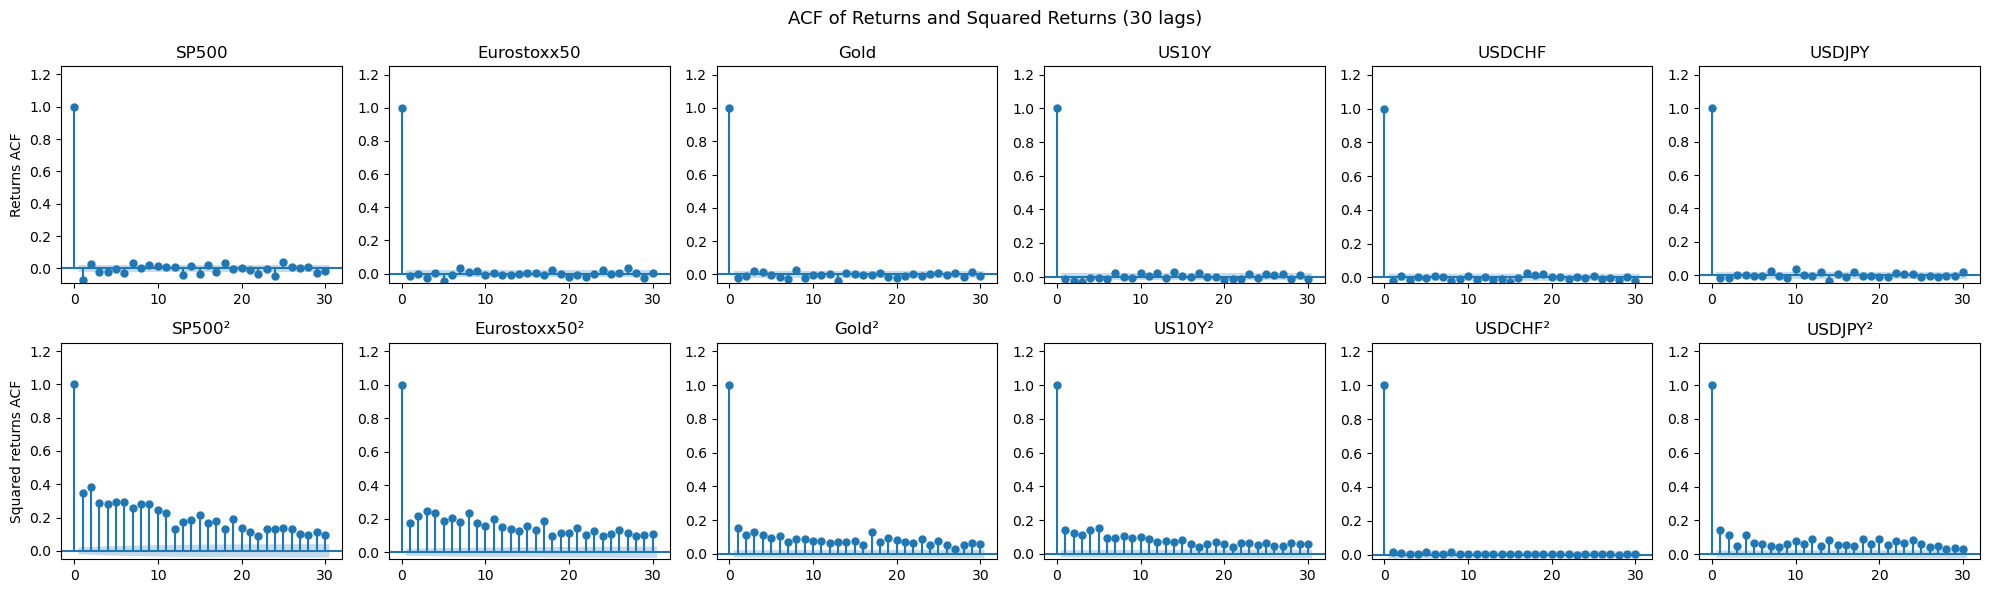

In [4]:
fig, axes = plt.subplots(2, len(returns.columns), figsize=(20, 6))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col],      ax=axes[0, i], lags=30, title=col,     auto_ylims=True)
    plot_acf(returns[col] ** 2, ax=axes[1, i], lags=30, title=f"{col}²", auto_ylims=True)
axes[0, 0].set_ylabel('Returns ACF')
axes[1, 0].set_ylabel('Squared returns ACF')
plt.suptitle('ACF of Returns and Squared Returns (30 lags)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/acf.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 2. Volatility Modelling

## Step 2.1: GJR-GARCH(1,1)-t

In [5]:
def fit_gjr(series):
    return arch_model(series, vol='GARCH', p=1, o=1, q=1, dist='studentst').fit(disp='off')


## Step 2.2: Estimate GJR-GARCH: Full Sample and Pre/Post

Estimated on the post-2010 sample (excluding the GFC) with Student-$t$ innovations. Full-sample conditional volatility feeds the DCC filter in Section 3.

> **Note:** the pre-COVID GJR-GARCH is estimated from `PRE_COVID_START = '2010-01-01'`
> onward, excluding the 2008 GFC. This restriction is applied consistently across
> Table 2, the persistence Wald test, and the Markov-switching block.

Pre-COVID                                              Post-COVID  \
                omega   alpha   gamma    beta       nu persistence      omega   
SP500          0.0384  0.0000  0.3734  0.7812   5.2437      0.9679     0.0346   
Eurostoxx50    0.0478  0.0000  0.2768  0.8393   6.1664      0.9777     0.0642   
Gold           0.0085  0.0484 -0.0253  0.9561   4.8697      0.9919     0.0371   
US10Y          0.0014  0.0457 -0.0176  0.9554  14.6202      0.9923     0.0051   
USDCHF         0.0013  0.0064  0.0359  0.9722   6.2335      0.9965     0.0159   
USDJPY         0.0026  0.0426  0.0033  0.9490   4.8294      0.9932     0.0086   

                                                          
              alpha   gamma    beta       nu persistence  
SP500        0.0000  0.2015  0.8626   6.8861      0.9634  
Eurostoxx50  0.0000  0.2342  0.8348   5.7466      0.9519  
Gold         0.1071 -0.0752  0.9008   5.6922      0.9702  
US10Y        0.0734  0.0423  0.8862  13.1206      0.9808  
USDCHF       0.0553 -0.0072  0.8795   7.3301      0.9312  
USDJPY       0.1061 -0.0307  0.8873   5.0108      0.9781

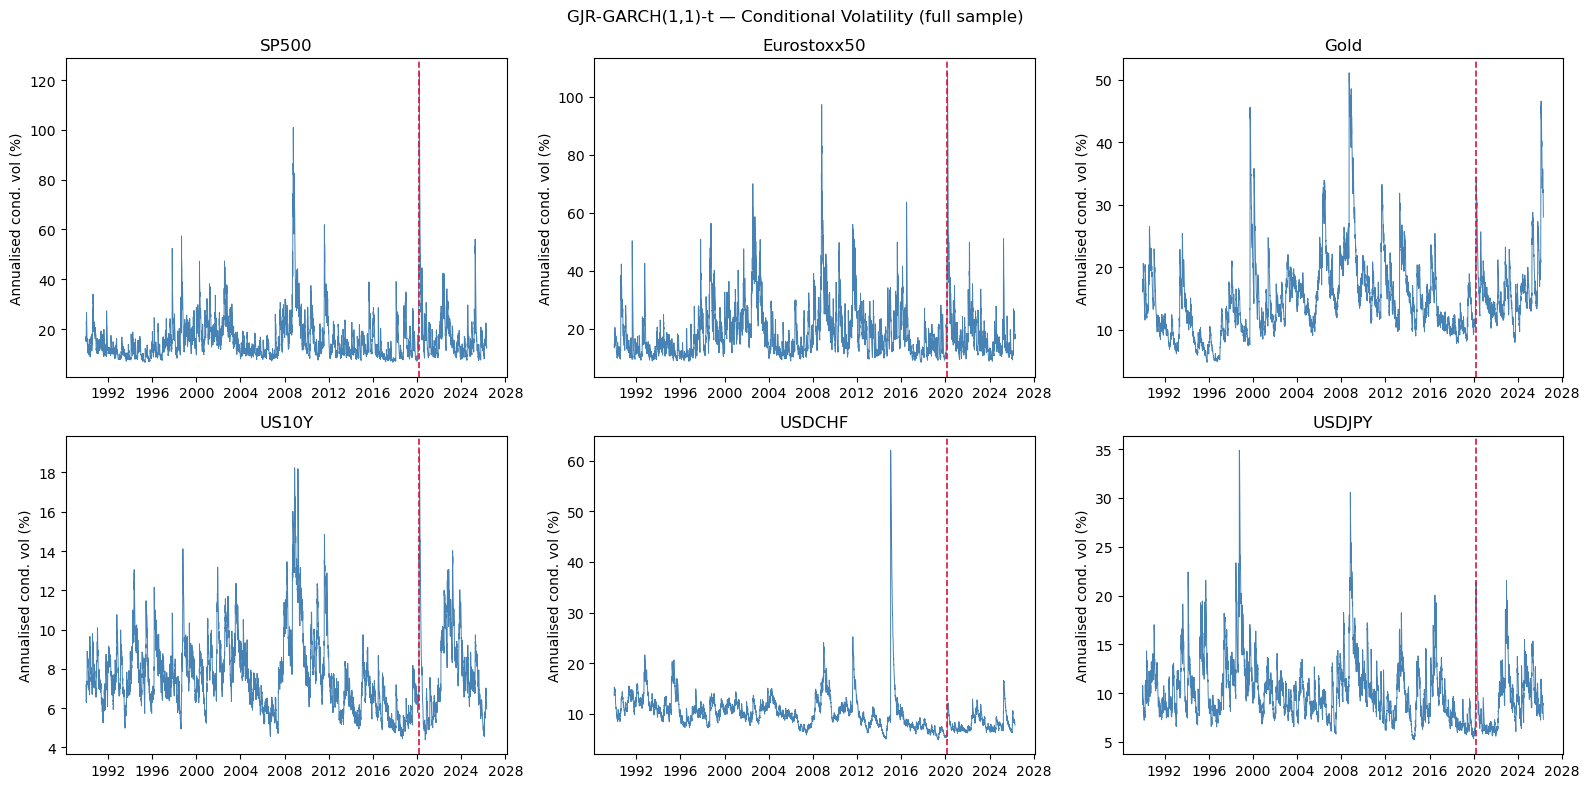

In [6]:
# Full-sample fits (used in DCC)
garch_full = {col: fit_gjr(returns[col]) for col in returns.columns}
# Pre / post fits (for parameter comparison)
garch_pre = {col: fit_gjr(ret_pre.loc[PRE_COVID_START:][col]) for col in returns.columns}
garch_post = {col: fit_gjr(ret_post[col]) for col in returns.columns}

def garch_summary(model_dict, label):
    rows = []
    for col, res in model_dict.items():
        p = res.params
        rows.append({
            'omega':       p['omega'],
            'alpha':       p['alpha[1]'],
            'gamma':       p['gamma[1]'],
            'beta':        p['beta[1]'],
            'nu':          p['nu'],
            'persistence': p['alpha[1]'] + 0.5*p['gamma[1]'] + p['beta[1]'],
        })
    df = pd.DataFrame(rows, index=model_dict.keys()).round(4)
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df

table2 = pd.concat([
    garch_summary(garch_pre,  'Pre-COVID'),
    garch_summary(garch_post, 'Post-COVID')
], axis=1)
display(table2)
table2.to_csv('outputs/tables/table2_gjr_params.csv')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, returns.columns):
    ax.plot(garch_full[col].conditional_volatility * np.sqrt(252),
            linewidth=0.7, color='steelblue')
    ax.axvline(COVID_DATE, color='crimson', linestyle='--', linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel('Annualised cond. vol (%)')
plt.suptitle('GJR-GARCH(1,1)-t — Conditional Volatility (full sample)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2.3: GARCH Diagnostics

Ljung-Box on squared standardized residuals at lag 10.

In [7]:
print("Ljung-Box on squared standardized residuals (p > 0.05 = well specified):")
for col, res in garch_full.items():
    z2 = (res.resid / res.conditional_volatility).dropna() ** 2
    p = acorr_ljungbox(z2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    flag = '✓' if p > 0.05 else '✗ ARCH remains'
    print(f"  {col:12s}  p = {p:.4f}  {flag}")

Ljung-Box on squared standardized residuals (p > 0.05 = well specified):
  SP500         p = 0.6776  ✓
  Eurostoxx50   p = 0.7455  ✓
  Gold          p = 0.0000  ✗ ARCH remains
  US10Y         p = 0.0701  ✓
  USDCHF        p = 1.0000  ✓
  USDJPY        p = 0.7183  ✓


## Step 2.3b: Wald Test: Did Persistence Change Significantly?

Tests $H_0: \pi_{\text{pre}} = \pi_{\text{post}}$ where $\pi = \alpha + \gamma/2 + \beta$, using the delta method for the variance of each estimate.

In [8]:
def persistence_wald(res_pre, res_post):
    """
    Wald test H0: persistence_pre == persistence_post.
    Uses delta method to get Var(pi) from each model's param covariance matrix.
    Returns: (pi_pre, pi_post, Z-stat, p-value)
    """
    def get_pi_and_var(res):
        p = res.params
        pi = p['alpha[1]'] + 0.5 * p['gamma[1]'] + p['beta[1]']
        # gradient of pi w.r.t. (alpha, gamma, beta) = (1, 0.5, 1)
        idx = list(res.params.index)
        c = np.zeros(len(idx))
        c[idx.index('alpha[1]')] = 1.0
        c[idx.index('gamma[1]')] = 0.5
        c[idx.index('beta[1]')]  = 1.0
        V = res.param_cov.values
        var_pi = float(c @ V @ c)
        return pi, var_pi

    pi_pre,  var_pre = get_pi_and_var(res_pre)
    pi_post, var_post = get_pi_and_var(res_post)
    Z = (pi_pre - pi_post) / np.sqrt(var_pre + var_post)
    pv = 2 * (1 - norm.cdf(abs(Z)))
    return pi_pre, pi_post, Z, pv

print(f"{'Asset':12s}  {'π_pre':>8s}  {'π_post':>8s}  {'Z-stat':>8s}  {'p-value':>8s}  Result")
print('-' * 65)
wald_persistence = {}
for col in returns.columns:
    pi_pre, pi_post, Z, pv = persistence_wald(garch_pre[col], garch_post[col])
    result = 'REJECT H₀ ✓' if pv < 0.05 else 'fail to reject'
    print(f"{col:12s}  {pi_pre:8.4f}  {pi_post:8.4f}  {Z:8.3f}  {pv:8.4f}  {result}")
    wald_persistence[col] = {'pi_pre': pi_pre, 'pi_post': pi_post, 'Z': Z, 'p': pv}

pd.DataFrame(wald_persistence).T.round(4).to_csv('outputs/tables/wald_persistence.csv')


Asset            π_pre    π_post    Z-stat   p-value  Result
-----------------------------------------------------------------
SP500           0.9679    0.9634     0.233    0.8155  fail to reject
Eurostoxx50     0.9777    0.9519     1.334    0.1821  fail to reject
Gold            0.9919    0.9702     1.421    0.1553  fail to reject
US10Y           0.9923    0.9808     0.983    0.3258  fail to reject
USDCHF          0.9965    0.9312     0.898    0.3694  fail to reject
USDJPY          0.9932    0.9781     1.128    0.2593  fail to reject


## Step 2.4: sup-F on GJR-GARCH Conditional Volatility

Applied to the GJR-GARCH conditional standard deviation series (post-2010 window) to test for a structural break in volatility level. This is a motivational step: an unstable volatility regime is a precondition for unstable correlations and hedge ratios.

The search window is restricted to post-2010 to exclude the 2008 GFC and focus on the COVID-related period. The conditional volatility itself comes from the full-sample GARCH, consistent with the DCC inputs in Section 3.

In [9]:

def supF_vol(series, trim=TRIM):
    """
    Vectorized O(T) sup-F test for a mean shift in `series`.
    Returns: (sup_F statistic, index of break, date of break, F-stat series)
    """
    y = series.dropna().values
    T = len(y)
    lo = int(trim * T)
    hi = T - int(trim * T)

    SSR_full = float(np.sum((y - y.mean()) ** 2))

    cs = np.cumsum(y)
    cs2 = np.cumsum(y ** 2)

    t_arr = np.arange(lo, hi)
    n1 = t_arr;      n2 = T - t_arr
    s1 = cs[t_arr - 1]
    s2 = cs[T - 1] - cs[t_arr - 1]
    s2_1 = cs2[t_arr - 1]
    s2_2 = cs2[T - 1] - cs2[t_arr - 1]

    SSR1 = s2_1 - s1 ** 2 / n1
    SSR2 = s2_2 - s2 ** 2 / n2
    num = (SSR_full - SSR1 - SSR2) / 1
    den = (SSR1 + SSR2) / (T - 2)
    F_arr = np.where(den > 0, num / den, 0.0)

    best = int(np.argmax(F_arr))
    t_star = int(t_arr[best])
    idx = series.dropna().index
    return float(F_arr[best]), t_star, idx[t_star], pd.Series(F_arr, index=idx[t_arr])


print('=' * 65)
print(f'sup-F on GJR-GARCH σ_t  |  search window: {PRE_COVID_START} onward')
print(f'Andrews (1993) 5% critical value (k=1, trim=15%): {SUPF_CV_5PCT}')
print('=' * 65)

supF_vol_results = {}
for col in returns.columns:
    sigma_series = garch_full[col].conditional_volatility.loc[PRE_COVID_START:]
    sup_F, t_idx, date_star, F_series = supF_vol(sigma_series)
    reject = sup_F > SUPF_CV_5PCT
    supF_vol_results[col] = {'sup_F': sup_F, 'break_date': date_star, 'reject': reject}
    flag = 'REJECT ✓  → structural break in volatility detected' if reject else 'fail to reject'
    print(f'\n{col}:')
    print(f'  sup-F = {sup_F:.2f}   {flag}')
    print(f'  Most likely break date: {date_star.date()}')

supF_vol_df = pd.DataFrame(supF_vol_results).T.round(3)
supF_vol_df.to_csv('outputs/tables/supF_volatility.csv')
display(supF_vol_df)


sup-F on GJR-GARCH σ_t  |  search window: 2010-01-01 onward
Andrews (1993) 5% critical value (k=1, trim=15%): 8.85

SP500:
  sup-F = 127.29   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2020-02-25

Eurostoxx50:
  sup-F = 236.27   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2012-08-16

Gold:
  sup-F = 291.84   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2023-11-02

US10Y:
  sup-F = 588.43   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2022-03-01

USDCHF:
  sup-F = 599.55   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2016-03-07

USDJPY:
  sup-F = 308.06   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2022-04-29


,sup_F,break_date,reject
SP500,127.286329,2020-02-25 00:00:00,True
Eurostoxx50,236.27089,2012-08-16 00:00:00,True
Gold,291.839467,2023-11-02 00:00:00,True
US10Y,588.428348,2022-03-01 00:00:00,True
USDCHF,599.552089,2016-03-07 00:00:00,True
USDJPY,308.061653,2022-04-29 00:00:00,True


---

# 3. Multivariate Dependence

## Step 3.1: DCC(1,1) — Engle (2002), Two-Step Estimation

DCC parameters $(a, b)$ are estimated on the full sample. This produces a single filtered correlation path consistent across pre- and post-COVID periods. We test each safe haven against both equity benchmarks (S&P 500 and Eurostoxx 50), yielding 8 correlation pairs.

In [10]:
std_resid = pd.DataFrame({
    col: garch_full[col].resid / garch_full[col].conditional_volatility
    for col in returns.columns
}).dropna()

u_arr = std_resid.values  # shape (T, N)
T, N = u_arr.shape
Q_bar = np.cov(u_arr.T)  # unconditional covariance of u_t


def dcc_loglik_neg(params, u, Q_bar):
    """Negative DCC correlation log-likelihood (Engle 2002, eq. 13)."""
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10

    T, N = u.shape
    Q = Q_bar.copy()
    ll = 0.0

    for t in range(1, T):
        ut_1 = u[t-1].reshape(-1, 1)
        Q = (1 - a - b) * Q_bar + a * (ut_1 @ ut_1.T) + b * Q

        # Normalize Q to correlation matrix R_t
        d_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
        R = d_inv @ Q @ d_inv

        # Log-likelihood contribution: log|R_t| + u_t' R_t^{-1} u_t - u_t' u_t
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e10
        ut = u[t]
        ll += logdet + float(ut @ np.linalg.solve(R, ut)) - float(ut @ ut)

    return 0.5 * ll  # negative log-likelihood


from scipy.optimize import minimize as sp_minimize

print('Estimating DCC(1,1) parameters via MLE ...')
res_dcc = sp_minimize(
    dcc_loglik_neg,
    x0=[0.05, 0.90],
    args=(u_arr, Q_bar),
    method = 'L-BFGS-B',
    bounds = [(1e-6, 0.499), (1e-6, 0.999)],
    options= {'ftol': 1e-9, 'gtol': 1e-7, 'maxiter': 500}
)

a_hat, b_hat = res_dcc.x
print(f'DCC estimates:  a = {a_hat:.6f},  b = {b_hat:.6f}')
print(f'Persistence (a+b) = {a_hat + b_hat:.6f}')
print(f'Converged: {res_dcc.success}  |  {res_dcc.message}')

if not res_dcc.success:
    warnings.warn('DCC optimisation did not converge — check starting values.')

def dcc_filter(u, a, b, Q_bar):
    """Filter the DCC correlation cube R (T×N×N) given estimated a, b."""
    T, N = u.shape
    Q = Q_bar.copy()
    R = np.zeros((T, N, N))
    R[0] = np.corrcoef(u.T)  # initialise with unconditional correlation

    for t in range(1, T):
        ut_1 = u[t-1].reshape(-1, 1)
        Q = (1 - a - b) * Q_bar + a * (ut_1 @ ut_1.T) + b * Q
        d_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
        R[t]  = d_inv @ Q @ d_inv

    return R    # shape (T, N, N)


R_dyn = dcc_filter(u_arr, a_hat, b_hat, Q_bar)
col_list = list(returns.columns)

dcc_corr_all = {}
for sh in SAFE_HAVENS:
    j_sh = col_list.index(sh)
    for bm in BENCHMARKS:
        j_bm = col_list.index(bm)
        key = f'{sh}_vs_{bm}'
        dcc_corr_all[key] = pd.Series(
            R_dyn[:, j_sh, j_bm], index=std_resid.index, name=key
        )

print(f'\nDCC correlation series computed for {len(dcc_corr_all)} pairs:')
print(list(dcc_corr_all.keys()))
pd.DataFrame({'a': [a_hat], 'b': [b_hat], 'persistence': [a_hat+b_hat]}).round(6)\
  .to_csv('outputs/tables/dcc_params.csv', index=False)


Estimating DCC(1,1) parameters via MLE ...
DCC estimates:  a = 0.018730,  b = 0.975633
Persistence (a+b) = 0.994363
Converged: True  |  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

DCC correlation series computed for 8 pairs:
['Gold_vs_SP500', 'Gold_vs_Eurostoxx50', 'US10Y_vs_SP500', 'US10Y_vs_Eurostoxx50', 'USDCHF_vs_SP500', 'USDCHF_vs_Eurostoxx50', 'USDJPY_vs_SP500', 'USDJPY_vs_Eurostoxx50']


## Step 3.2: Conditional Beta Decomposition

For each safe haven $j$ and benchmark $m$:

$$\beta_{j,t} = \rho_{j,m,t} \times \frac{\sigma_{j,t}}{\sigma_{m,t}}$$

Decomposition into a correlation channel ($\rho$) and a relative-volatility channel ($\sigma_j/\sigma_m$).

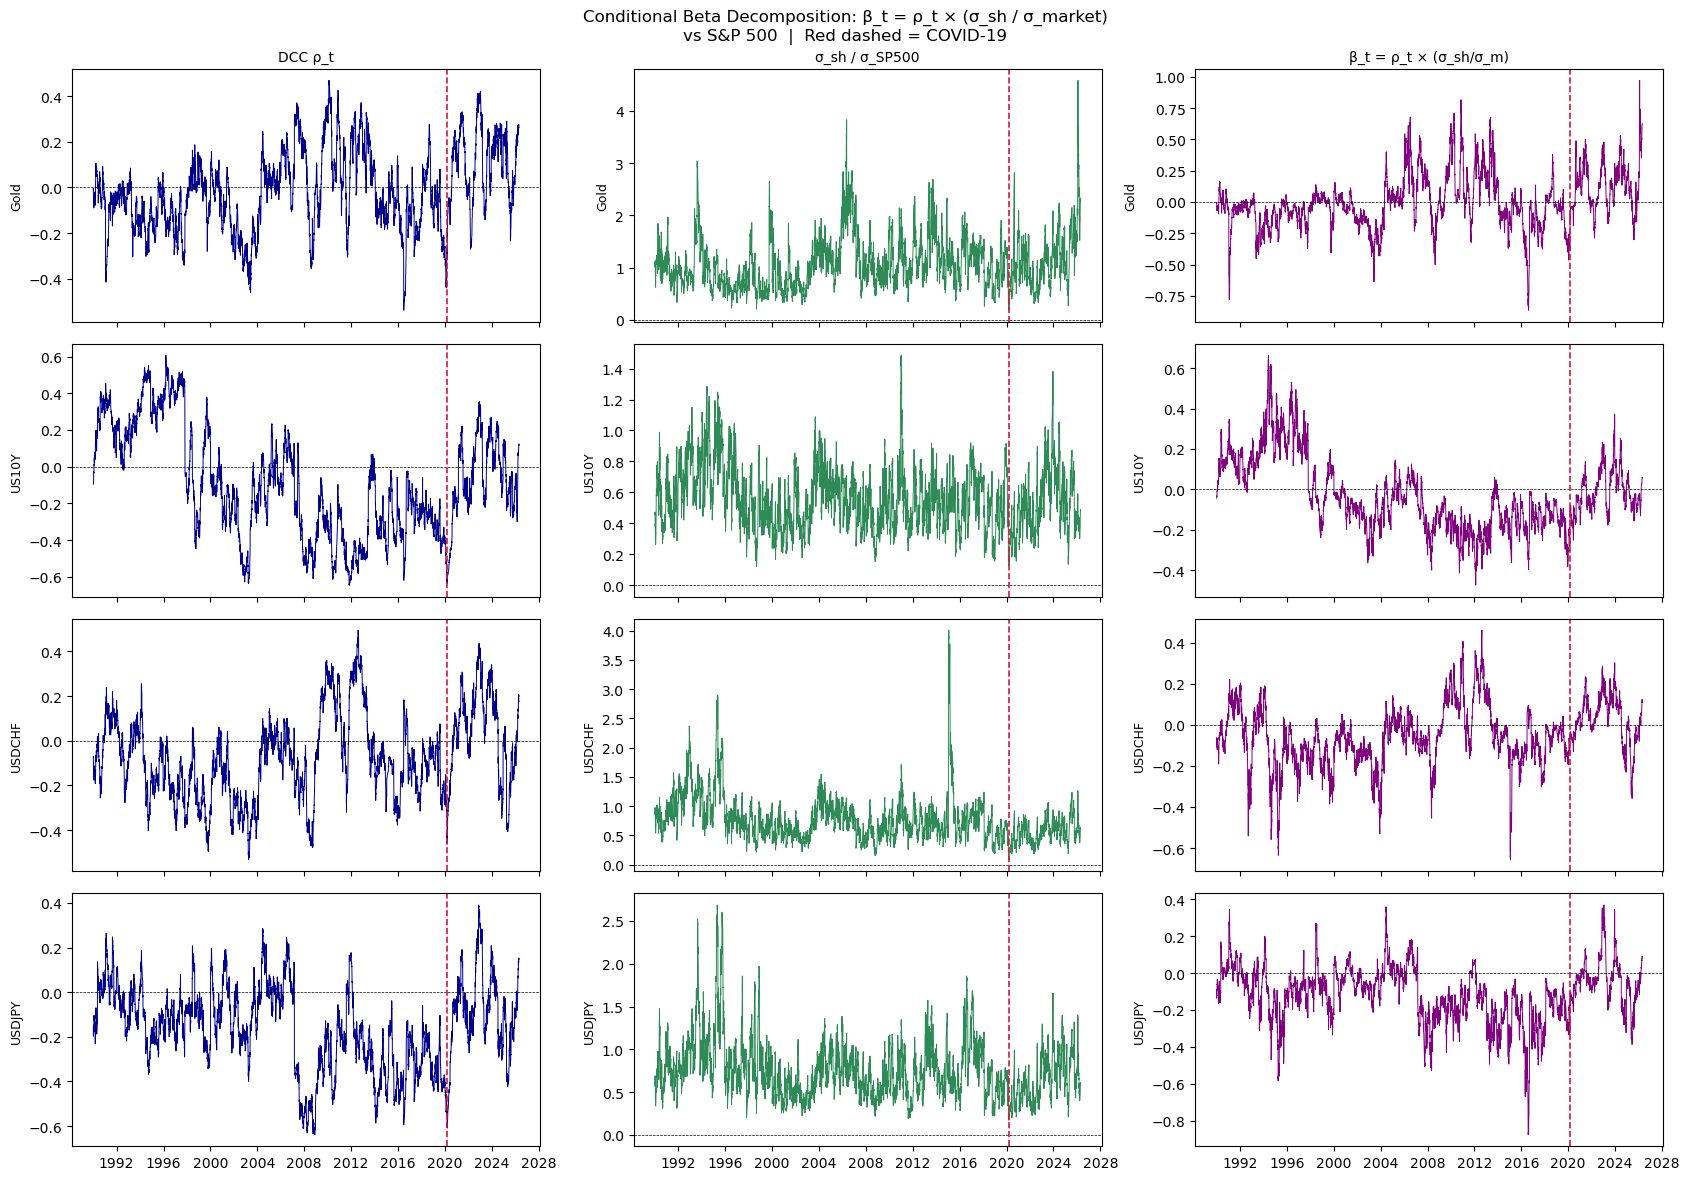

In [11]:
# Compute conditional beta for all pairs
dcc_beta_all = {}
for sh in SAFE_HAVENS:
    sigma_sh = garch_full[sh].conditional_volatility.loc[std_resid.index]
    for bm in BENCHMARKS:
        sigma_bm = garch_full[bm].conditional_volatility.loc[std_resid.index]
        key = f"{sh}_vs_{bm}"
        dcc_beta_all[key] = dcc_corr_all[key] * (sigma_sh / sigma_bm)

fig, axes = plt.subplots(4, 3, figsize=(17, 12), sharex=True)
for i, sh in enumerate(SAFE_HAVENS):
    key = f"{sh}_vs_SP500"
    rho_t = dcc_corr_all[key]
    sigma_sh = garch_full[sh].conditional_volatility.loc[std_resid.index]
    sigma_sp = garch_full['SP500'].conditional_volatility.loc[std_resid.index]

    for ax, (data, title, color) in zip(axes[i], [
        (rho_t,               'DCC ρ_t',             'darkblue'),
        (sigma_sh / sigma_sp, 'σ_sh / σ_SP500',      'seagreen'),
        (dcc_beta_all[key],   'β_t = ρ_t × (σ_sh/σ_m)', 'purple'),
    ]):
        ax.plot(data.index, data.values, linewidth=0.7, color=color)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(COVID_DATE, color='crimson', linestyle='--', linewidth=1.2)
        ax.set_ylabel(sh, fontsize=9)
        if i == 0: ax.set_title(title, fontsize=10)

plt.suptitle('Conditional Beta Decomposition: β_t = ρ_t × (σ_sh / σ_market)\n'
             'vs S&P 500  |  Red dashed = COVID-19', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/conditional_beta.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3.3: Rolling 252-Day Correlation

Non-parametric counterpart to the DCC for robustness. All 8 safe-haven/benchmark pairs.

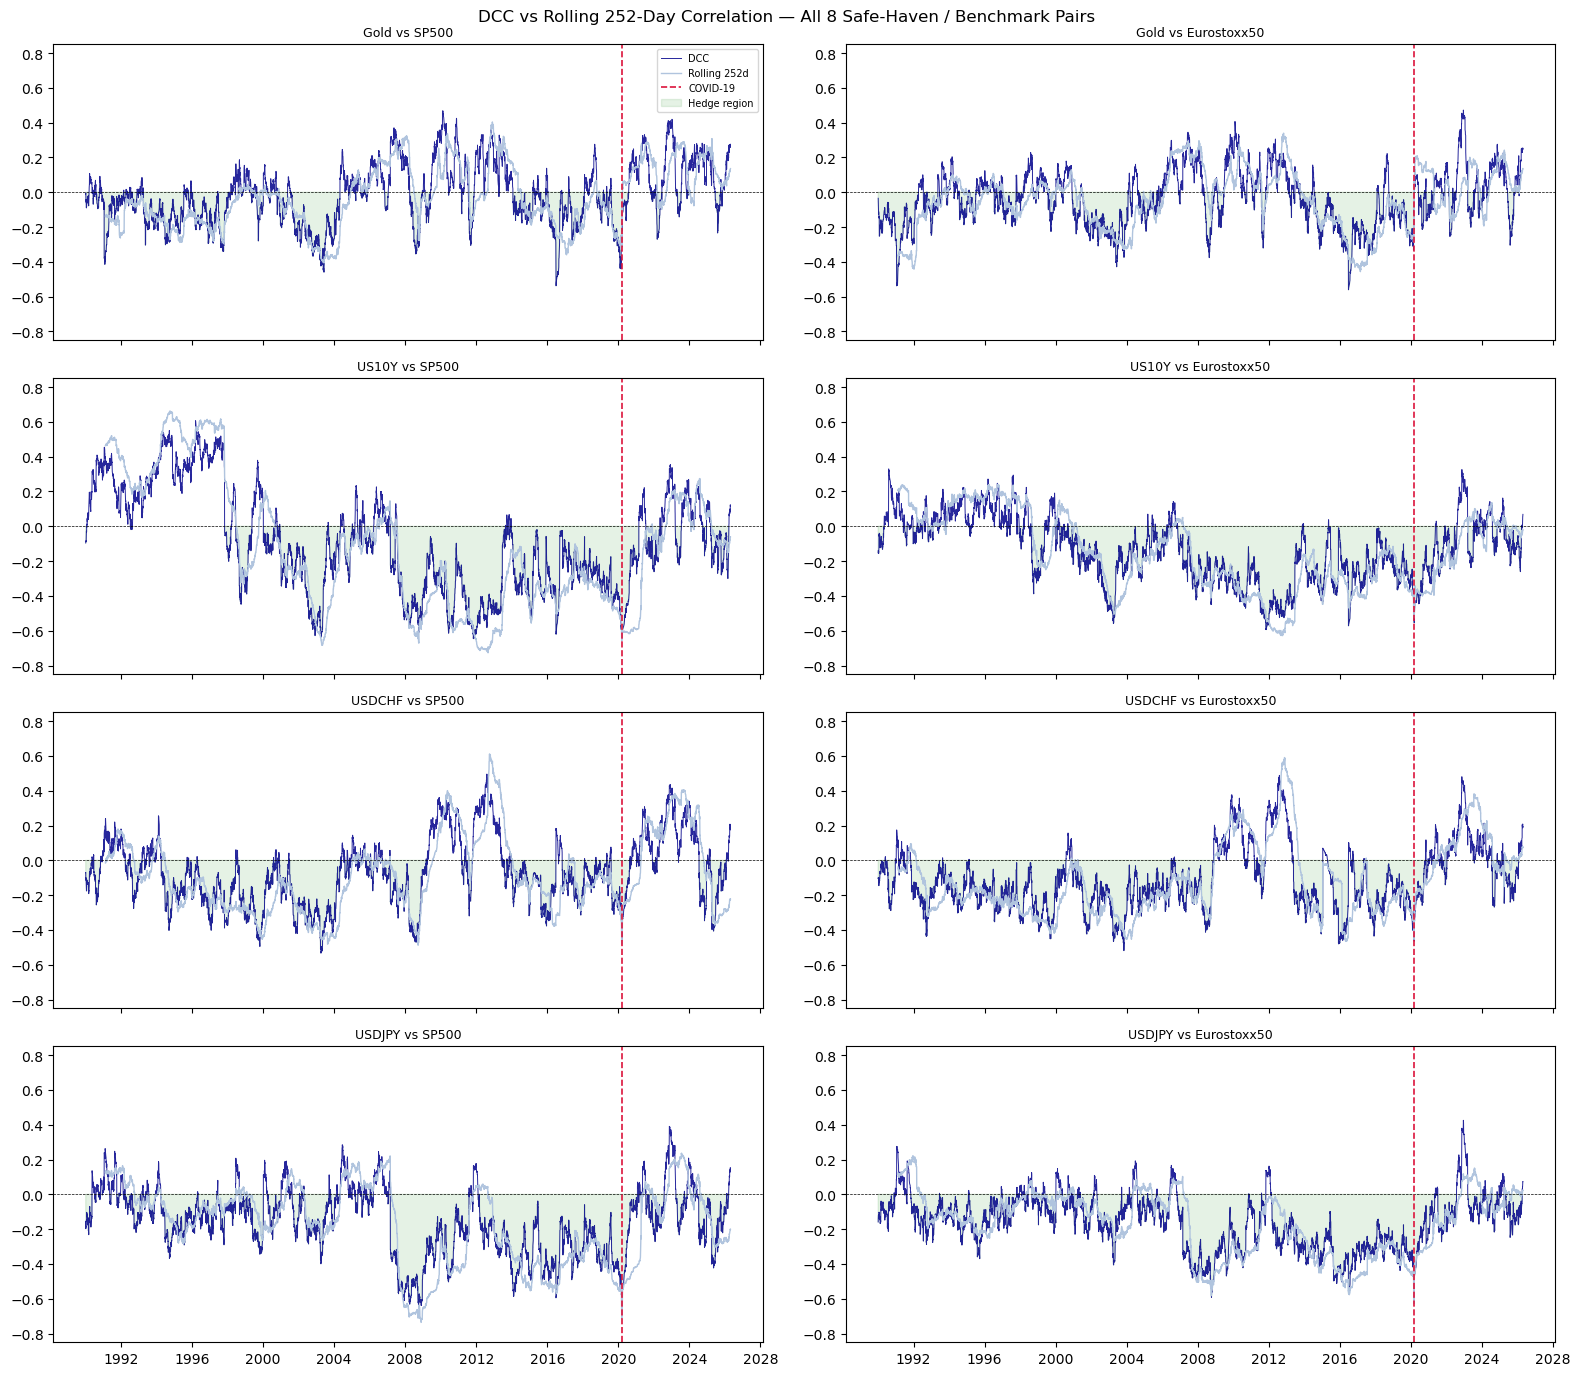

In [12]:
rolling_corr_all = {}
for sh in SAFE_HAVENS:
    for bm in BENCHMARKS:
        key = f"{sh}_vs_{bm}"
        rolling_corr_all[key] = (
            returns[sh].rolling(ROLL_WIN).corr(returns[bm]).dropna()
        )

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
for i, sh in enumerate(SAFE_HAVENS):
    for j, bm in enumerate(BENCHMARKS):
        key = f"{sh}_vs_{bm}"
        ax = axes[i, j]
        ax.plot(dcc_corr_all[key].index, dcc_corr_all[key].values,
                color='darkblue', linewidth=0.7, label='DCC', alpha=0.85)
        ax.plot(rolling_corr_all[key].index, rolling_corr_all[key].values,
                color='lightsteelblue', linewidth=1.0, label='Rolling 252d')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(COVID_DATE, color='crimson', linestyle='--',
                   linewidth=1.2, label='COVID-19')
        ax.fill_between(dcc_corr_all[key].index, dcc_corr_all[key].values, 0,
                        where=(dcc_corr_all[key].values < 0),
                        alpha=0.10, color='green', label='Hedge region')
        ax.set_ylim(-0.85, 0.85)
        ax.set_title(f'{sh} vs {bm}', fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.suptitle('DCC vs Rolling 252-Day Correlation — All 8 Safe-Haven / Benchmark Pairs',
             fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 4. Structural Breaks & Regimes

## Step 4.2: Structural Break Tests: sup-F then Bai-Perron

Two-stage structural break testing on each DCC correlation series.

**Stage 1 — sup-F (Andrews, 1993).** Screens for evidence of at least one break. 5% critical value = 8.85 (15% trimming, $k=1$).

**Stage 2 — Bai-Perron (1998, 2003).** For pairs where sup-F rejects, selects the number and location of breaks via BIC minimization over $m \in \{0,1,2,3\}$.

**Note:** DCC series are highly persistent ($\rho_1 \approx 0.99$), which may cause BIC to slightly over-detect breaks.

In [13]:
def select_m_bic(ssr_by_m, T, m_max=5):
    """
    Bai-Perron BIC selection.
    BIC(m) = T * log(SSR(m) / T) + (m + 1) * log(T)
    where (m+1) is the number of segment means estimated.
    Returns the m in {0, 1, ..., m_max} that minimizes BIC.
    """
    bic = {m: T * np.log(ssr_by_m[m] / T) + (m + 1) * np.log(T)
           for m in range(m_max + 1)}
    optimal_m = min(bic, key=bic.get)
    return optimal_m, bic

def supF_test(series, trim=TRIM):
    y = series.dropna().values
    T = len(y)
    lo = int(trim * T)
    hi = T - int(trim * T)

    SSR_full = float(np.sum((y - y.mean())**2))

    cs = np.cumsum(y)
    cs2 = np.cumsum(y ** 2)

    t_arr = np.arange(lo, hi)
    n1 = t_arr
    n2 = T - t_arr

    s1 = cs[t_arr - 1]
    s2 = cs[T - 1] - cs[t_arr - 1]
    s2_1 = cs2[t_arr - 1]
    s2_2 = cs2[T - 1] - cs2[t_arr - 1]

    # SSR = Σy² - (Σy)²/n  for each segment
    SSR1 = s2_1 - s1 ** 2 / n1
    SSR2 = s2_2 - s2 ** 2 / n2
    num = (SSR_full - SSR1 - SSR2) / 1
    den = (SSR1 + SSR2) / (T - 2)
    F_arr = np.where(den > 0, num / den, 0.0)

    best_local = int(np.argmax(F_arr))
    t_star = int(t_arr[best_local])
    sup_F = float(F_arr[best_local])
    all_dates = series.dropna().index
    F_series = pd.Series(F_arr, index=all_dates[t_arr], name='F_stat')
    return sup_F, t_star, all_dates[t_star], F_series


supF_results = {}
bp_results = {}

print("=" * 70)
print(f"STAGE 1 — sup-F  (Andrews 1993  5% CV = {SUPF_CV_5PCT})")
print("=" * 70)

PAIRS = [f"{sh}_vs_{bm}" for sh in SAFE_HAVENS for bm in BENCHMARKS]

for key in PAIRS:
    series = dcc_corr_all[key]
    sup_F, t_idx, date_star, F_series = supF_test(series)
    reject = sup_F > SUPF_CV_5PCT
    supF_results[key] = {'sup_F': sup_F, 'date': date_star, 'reject': reject}

    flag = '→ REJECT ✓  (break exists, proceed to Bai-Perron)' if reject else '→ fail to reject'
    print(f"\n{key}:")
    print(f"  sup-F = {sup_F:.2f}   {flag}")
    print(f"  sup-F estimated break: {date_star.date()}")

    if reject:
        y_bp = series.dropna().values.reshape(-1, 1)
        idx_ = series.dropna().index
        model_bp = rpt.Dynp(model="l2", min_size=MIN_SEG_BP, jump=5).fit(y_bp)

        def total_ssr(bkps):
            segs = [0] + bkps
            ssr = 0
            for k in range(len(segs) - 1):
                seg = y_bp[segs[k]:segs[k+1]]
                ssr += float(np.sum((seg - seg.mean())**2))
            return ssr

        ssr_by_m = {0: total_ssr([len(y_bp)])}
        bkps_by_m = {}
        for m in [1, 2, 3]:
            bkps_m = model_bp.predict(n_bkps=m)
            ssr_by_m[m]  = total_ssr(bkps_m)
            bkps_by_m[m] = bkps_m[:-1]  # drop sentinel

        # BIC-based selection (Bai-Perron standard)
        T_eff = len(y_bp)
        optimal_m, bic_by_m = select_m_bic(ssr_by_m, T_eff, m_max=3)

        break_dates = [idx_[b] for b in bkps_by_m.get(optimal_m, [])]
        bp_results[key] = {'optimal_m': optimal_m, 'break_dates': break_dates,
                           'ssr_by_m': ssr_by_m, 'bic_by_m': bic_by_m}

        print(f"  Bai-Perron BIC selection: optimal m = {optimal_m}")
        for m in range(4):
            print(f"    m={m}: SSR = {ssr_by_m[m]:.4f}, BIC = {bic_by_m[m]:.2f}")
        for d in break_dates:
            print(f"  → Break detected: {d.date()}")
    else:
        bp_results[key] = {'optimal_m': 0, 'break_dates': [], 'ssr_by_m': {}}

bp_table = pd.DataFrame({
    k: [str(d.date()) for d in v['break_dates']] +
       [''] * (3 - len(v['break_dates']))
    for k, v in bp_results.items()
}, index=['Break 1', 'Break 2', 'Break 3']).T
bp_table.to_csv('outputs/tables/bai_perron_breaks.csv')
display(bp_table)

STAGE 1 — sup-F  (Andrews 1993  5% CV = 8.85)

Gold_vs_SP500:
  sup-F = 1934.49   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated break: 2004-04-29
  Bai-Perron BIC selection: optimal m = 3
    m=0: SSR = 255.7016, BIC = -29665.29
    m=1: SSR = 208.1834, BIC = -31398.84
    m=2: SSR = 194.3609, BIC = -31972.11
    m=3: SSR = 158.8112, BIC = -33675.23
  → Break detected: 2004-04-27
  → Break detected: 2014-01-22
  → Break detected: 2020-08-04

Gold_vs_Eurostoxx50:
  sup-F = 416.36   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated break: 2020-10-29
  Bai-Perron BIC selection: optimal m = 3
    m=0: SSR = 215.8500, BIC = -31101.35
    m=1: SSR = 202.2916, BIC = -31642.18
    m=2: SSR = 179.4962, BIC = -32646.49
    m=3: SSR = 153.1235, BIC = -33984.36
  → Break detected: 2006-01-06
  → Break detected: 2013-10-10
  → Break detected: 2020-03-12

US10Y_vs_SP500:
  sup-F = 9213.57   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated br

,Break 1,Break 2,Break 3
Gold_vs_SP500,2004-04-27,2014-01-22,2020-08-04
Gold_vs_Eurostoxx50,2006-01-06,2013-10-10,2020-03-12
US10Y_vs_SP500,1997-10-29,2007-08-08,2021-02-26
US10Y_vs_Eurostoxx50,1998-08-24,2007-08-15,2021-04-08
USDCHF_vs_SP500,2009-04-02,2013-05-30,2020-08-18
USDCHF_vs_Eurostoxx50,2008-11-14,2013-05-21,2020-09-24
USDJPY_vs_SP500,2007-03-01,2009-02-25,2020-08-18
USDJPY_vs_Eurostoxx50,2007-03-01,2008-12-24,2021-01-26


## Step 4.3: Markov-Switching (2-State)

Two-state model with switching mean and variance on each DCC correlation series. State 1 = hedging regime (low/negative correlation), State 2 = breakdown regime (high positive correlation).

We use Markov switching rather than TAR/SETAR because the latter ties regime persistence to the autocorrelation of the threshold variable, providing no free parameter to model duration independently (cf. Lecture 12).

In [14]:
def fit_ms(series):
    return MarkovRegression(series, k_regimes=2, trend='c', switching_variance=True).fit(disp=False, maxiter=300)

ms_full = {}
ms_pre = {}
ms_post = {}

split = pd.Timestamp(SPLIT_DATE)

for key in PAIRS:
    s = dcc_corr_all[key]
    try:
        ms_full[key] = fit_ms(s)
        ms_pre[key]  = fit_ms(s.loc[PRE_COVID_START:split])
        ms_post[key] = fit_ms(s.loc[split:])
    except Exception as e:
        print(f"{key}: MS failed — {e}")

# Ensure regime 2 = higher mean (breakdown)
def ms_row(res, asset, period):
    p = res.params
    breakdown_idx = 0 if p['const[0]'] > p['const[1]'] else 1
    calm_idx = 1 - breakdown_idx
    try:
        p11 = float(res.regime_transition[calm_idx, calm_idx, 0])  # calm regime persistence
        p22 = float(res.regime_transition[breakdown_idx, breakdown_idx, 0])  # breakdown regime persistence
    except Exception:
        p11 = p.get(f'p[{calm_idx}->{calm_idx}]', np.nan)
        p22 = p.get(f'p[{breakdown_idx}->{breakdown_idx}]', np.nan)
    return {
        'Pair': asset, 'Period': period,
        'p11': round(p11, 4), 'p22': round(p22, 4),
        'D1 (days)': round(1 / (1 - p11), 1) if p11 < 1 else np.nan,
        'D2 (days)': round(1 / (1 - p22), 1) if p22 < 1 else np.nan,
    }

table4_rows = []
for key in PAIRS:
    if key in ms_pre:  table4_rows.append(ms_row(ms_pre[key],  key, 'Pre-COVID'))
    if key in ms_post: table4_rows.append(ms_row(ms_post[key], key, 'Post-COVID'))
table4 = pd.DataFrame(table4_rows).set_index(['Pair', 'Period']).round(4)
display(table4)
table4.to_csv('outputs/tables/table4_ms_params.csv')





p11     p22  D1 (days)  D2 (days)
Pair                  Period                                          
Gold_vs_SP500         Pre-COVID   0.9936  0.9909      155.6      109.7
                      Post-COVID  0.9879  0.9904       82.4      104.7
Gold_vs_Eurostoxx50   Pre-COVID   0.9948  0.9944      192.4      177.8
                      Post-COVID  0.9888  0.9898       89.5       97.8
US10Y_vs_SP500        Pre-COVID   0.9896  0.9891       95.9       91.5
                      Post-COVID  0.9942  0.9926      171.7      135.6
US10Y_vs_Eurostoxx50  Pre-COVID   0.9903  0.9936      103.1      155.2
                      Post-COVID  0.9941  0.9876      169.2       80.4
USDCHF_vs_SP500       Pre-COVID   0.9978  0.9952      456.2      210.3
                      Post-COVID  0.9943  0.9954      174.7      215.7
USDCHF_vs_Eurostoxx50 Pre-COVID   0.9960  0.9945      247.0      183.0
                      Post-COVID  0.9834  0.9781       60.2       45.6
USDJPY_vs_SP500       Pre-COVID   0.9900  0.9905      100.0      105.6
                      Post-COVID  0.9880  0.9860       83.2       71.6
USDJPY_vs_Eurostoxx50 Pre-COVID   0.9960  0.9859      252.6       71.1
                      Post-COVID  0.9821  0.9812       55.8       53.3

## Step 4.4: Wald Test: Regime Parameter Stability

Tests $H_0: \theta_{\text{pre}} = \theta_{\text{post}}$ where $\theta = (\mu_1, \mu_2, \sigma_1, \sigma_2, p_{11}, p_{22})$, using 2020-03-01 as the pre/post split.

$$W = (\hat\theta_{\text{pre}} - \hat\theta_{\text{post}})^\top [V_{\text{pre}} + V_{\text{post}}]^{-1} (\hat\theta_{\text{pre}} - \hat\theta_{\text{post}}) \sim \chi^2(k)$$

WALD TEST: H₀ — Markov switching parameters stable across break date
All 8 safe-haven / benchmark pairs

Gold_vs_SP500  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 458.41,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 109.7 days, post = 104.7 days

Gold_vs_Eurostoxx50  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 918.51,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 177.8 days, post = 97.8 days

US10Y_vs_SP500  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 6141.29,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 91.5 days, post = 135.6 days

US10Y_vs_Eurostoxx50  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 7061.31,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — 

,W,k,p,D_bad_pre,D_bad_post
Gold_vs_SP500,458.409,6.0,0.0,109.7,104.7
Gold_vs_Eurostoxx50,918.513,6.0,0.0,177.8,97.8
US10Y_vs_SP500,6141.289,6.0,0.0,91.5,135.6
US10Y_vs_Eurostoxx50,7061.314,6.0,0.0,155.2,80.4
USDCHF_vs_SP500,188.155,6.0,0.0,210.3,215.7
USDCHF_vs_Eurostoxx50,1886.829,6.0,0.0,183.0,45.6
USDJPY_vs_SP500,6178.673,6.0,0.0,105.6,71.6
USDJPY_vs_Eurostoxx50,6430.640,6.0,0.0,71.1,53.3


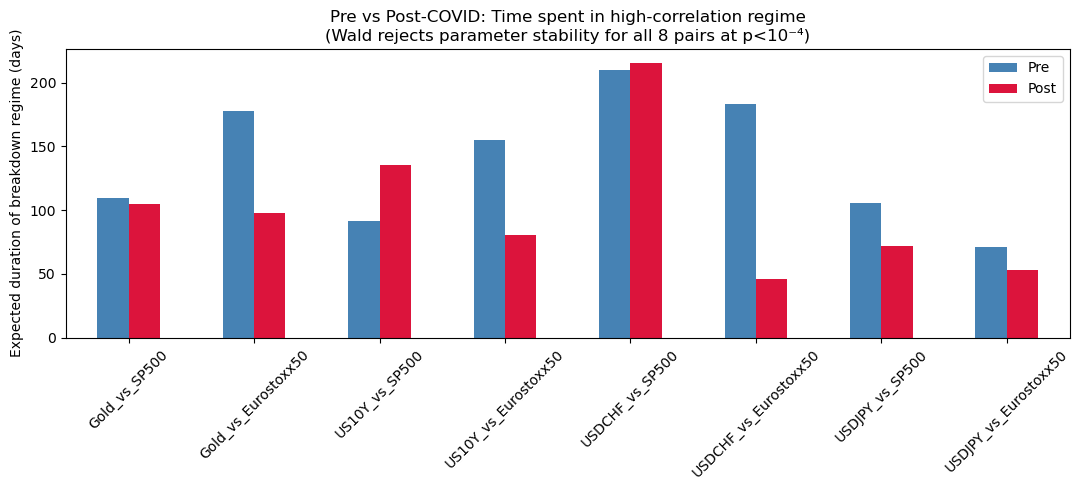

In [15]:
def align_ms_params(res):
    theta = res.params.values.copy()
    V = res.cov_params().values.copy()
    idx = list(res.params.index)
    c0_idx = idx.index('const[0]')
    c1_idx = idx.index('const[1]')
    if theta[c0_idx] > theta[c1_idx]:
        n = len(theta)
        J = np.eye(n)
        new_theta = theta.copy()
        for name in idx:
            src_idx = idx.index(name)
            if name == 'p[0->0]':
                dest_idx = idx.index('p[1->0]')
                new_theta[dest_idx] = 1.0 - theta[src_idx]
                J[dest_idx, src_idx] = -1.0
                J[dest_idx, dest_idx] = 0.0
                J[src_idx, src_idx]  = 0.0
            elif name == 'p[1->0]':
                dest_idx = idx.index('p[0->0]')
                new_theta[dest_idx] = 1.0 - theta[src_idx]
                J[dest_idx, src_idx] = -1.0
                J[dest_idx, dest_idx] = 0.0
                J[src_idx, src_idx]  = 0.0
            elif name.endswith('[0]'):
                dest_name = name[:-3] + '[1]'
                dest_idx = idx.index(dest_name)
                new_theta[dest_idx] = theta[src_idx]
                J[dest_idx, src_idx] = 1.0
                J[dest_idx, dest_idx] = 0.0
                J[src_idx, src_idx]  = 0.0
            elif name.endswith('[1]'):
                dest_name = name[:-3] + '[0]'
                dest_idx = idx.index(dest_name)
                new_theta[dest_idx] = theta[src_idx]
                J[dest_idx, src_idx] = 1.0
                J[dest_idx, dest_idx] = 0.0
                J[src_idx, src_idx]  = 0.0
        new_V = J @ V @ J.T
        return new_theta, new_V
    else:
        return theta, V
        
print("=" * 70)
print("WALD TEST: H₀ — Markov switching parameters stable across break date")
print("All 8 safe-haven / benchmark pairs")
print("=" * 70)

wald_results = {}

for key in PAIRS:
    split = pd.Timestamp(SPLIT_DATE)
    s_full = dcc_corr_all[key]
    s_pre = s_full.loc[PRE_COVID_START:split]
    s_post = s_full.loc[split:]

    print(f"\n{key}  (split at {split.date()}, "
          f"pre={len(s_pre)} obs, post={len(s_post)} obs)")

    if len(s_pre) < 60 or len(s_post) < 60:
        print(f"  Insufficient observations — skipping")
        continue

    try:
        ms_pre_wald = fit_ms(s_pre)
        ms_post_wald = fit_ms(s_post)

        theta_pre_aligned,  V_pre_aligned = align_ms_params(ms_pre_wald)
        theta_post_aligned, V_post_aligned = align_ms_params(ms_post_wald)
        diff = theta_pre_aligned - theta_post_aligned
        V_sum = V_pre_aligned + V_post_aligned
        W = float(diff @ np.linalg.solve(V_sum, diff))
        k = len(diff)
        pv = 1 - stats.chi2.cdf(W, df=k)

        print(f"  Wald W = {W:.2f},  k = {k},  p = {pv:.4f}", end='  ')
        if pv < 0.05:
            print("→ REJECT H₀: regime structure changed — structural break in regime dynamics")
        else:
            print("→ fail to reject H₀: same regime dynamics, "
                "market spent more time in bad-hedge regime post-COVID")

        # Breakdown regime persistence
        d_pre = ms_row(ms_pre_wald,  key, 'Pre-COVID')['D2 (days)']
        d_post = ms_row(ms_post_wald, key, 'Post-COVID')['D2 (days)']
        print(f"  E[duration bad regime]: pre = {d_pre:.1f} days, post = {d_post:.1f} days")

        wald_results[key] = {'W': W, 'k': k, 'p': pv,
                            'D_bad_pre': d_pre, 'D_bad_post': d_post}

    except Exception as e:
        print(f"  Estimation failed: {e}")

wald_table = pd.DataFrame(wald_results).T.round(3)
display(wald_table)
wald_table.to_csv('outputs/tables/wald_ms.csv')

durations = pd.DataFrame({
    'Pre': [wald_results[k]['D_bad_pre']  for k in PAIRS],
    'Post':[wald_results[k]['D_bad_post'] for k in PAIRS],
}, index=PAIRS)

fig, ax = plt.subplots(figsize=(11, 5))
durations.plot.bar(ax=ax, color=['steelblue', 'crimson'])
ax.set_ylabel('Expected duration of breakdown regime (days)')
ax.set_title('Pre vs Post-COVID: Time spent in high-correlation regime\n'
             '(Wald rejects parameter stability for all 8 pairs at p<10⁻⁴)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('outputs/figures/regime_duration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 5. Economic Magnitude of the Covariance Shift

**Equal Risk Contribution (ERC)** weights are computed pre and post COVID. The cost of inaction measures additional annualised portfolio volatility from failing to update the allocation:

$$\text{Cost} = \sqrt{w_{pre}^\top \Sigma_{post}\, w_{pre}} - \sqrt{w_{post}^\top \Sigma_{post}\, w_{post}}$$

In [16]:
from scipy.optimize import minimize as sp_min
N = returns.shape[1]
w0 = np.ones(N) / N
bounds = tuple((0.0, 0.70) for _ in range(N))
cons_sum = {'type': 'eq', 'fun': lambda w: w.sum() - 1.0}
def erc_objective(w, cov):
    """Minimize variance of risk contributions across assets."""
    port_vol = np.sqrt(w @ cov @ w)
    mrc = (cov @ w) / port_vol  # marginal risk contribution
    rc = w * mrc  # risk contribution per asset
    return ((rc - rc.mean()) ** 2).sum()
cov_pre = ret_pre.cov().values * 252  # annualised
cov_post = ret_post.cov().values * 252
w_pre = sp_min(erc_objective, w0, args=(cov_pre,),
                bounds=bounds, constraints=cons_sum, method='SLSQP').x
w_post = sp_min(erc_objective, w0, args=(cov_post,),
                bounds=bounds, constraints=cons_sum, method='SLSQP').x
erc_weights = pd.DataFrame(
    {'Pre-COVID': w_pre, 'Post-COVID': w_post},
    index=returns.columns
).round(4)
print('ERC weights — Pre vs Post COVID:')
display(erc_weights)
erc_weights.to_csv('outputs/tables/erc_weights.csv')
vol_pre_on_pre = np.sqrt(w_pre @ cov_pre @ w_pre)  # pre weights, pre Σ
vol_post_on_post = np.sqrt(w_post @ cov_post @ w_post)  # post weights, post Σ
vol_pre_on_post = np.sqrt(w_pre @ cov_post @ w_pre)  # pre weights, post Σ (inaction)
cost = vol_pre_on_post - vol_post_on_post
print(f'\nAnnualised portfolio vol:')
print(f'  Pre weights  × Pre  Σ : {vol_pre_on_pre:.2f}%  (in-sample baseline)')
print(f'  Post weights × Post Σ : {vol_post_on_post:.2f}%  (optimal post-COVID)')
print(f'  Pre weights  × Post Σ : {vol_pre_on_post:.2f}%  (cost of inaction)')
print(f'\nCost of not updating allocation: +{cost:.2f}% annualised volatility')
pd.DataFrame([{
    'vol_pre_on_pre':   round(vol_pre_on_pre,   2),
    'vol_post_on_post': round(vol_post_on_post, 2),
    'vol_pre_on_post':  round(vol_pre_on_post,  2),
    'cost_pct':         round(cost,           1),
}]).to_csv('outputs/tables/cost_of_inaction.csv', index=False)


ERC weights — Pre vs Post COVID:


,Pre-COVID,Post-COVID
SP500,0.1334,0.1101
Eurostoxx50,0.1092,0.1114
Gold,0.1202,0.1042
US10Y,0.2988,0.2606
USDCHF,0.1542,0.2172
USDJPY,0.1842,0.1964



Annualised portfolio vol:
  Pre weights  × Pre  Σ : 5.60%  (in-sample baseline)
  Post weights × Post Σ : 6.96%  (optimal post-COVID)
  Pre weights  × Post Σ : 7.16%  (cost of inaction)

Cost of not updating allocation: +0.19% annualised volatility


---

# 6. Results Summary

Consolidated table: sup-F break detection, Bai-Perron break dates, Markov switching expected durations, and Wald test verdict — all 8 safe-haven/benchmark pairs.

In [17]:
summary = []
for key in PAIRS:
    sh, bm = key.split('_vs_')
    sup = supF_results.get(key, {})
    bp = bp_results.get(key, {})
    wd = wald_results.get(key, {})  
    bd_str = ', '.join(str(d.date()) for d in bp.get('break_dates', [])) or 'None'

    summary.append({
        'Pair':            key,
        'sup-F stat':      round(sup.get('sup_F', np.nan), 2),
        'Break detected':  'Yes' if sup.get('reject') else 'No',
        'BP breaks (m)':   bp.get('optimal_m', 0),
        'Break date(s)':   bd_str,
        'Wald p':          round(wd.get('p', np.nan), 4),
        'E[D_bad] pre (d)':  round(wd.get('D_bad_pre',  np.nan), 1),
        'E[D_bad] post (d)': round(wd.get('D_bad_post', np.nan), 1),
    })

summary_df = pd.DataFrame(summary)
print("\n" + "="*80 + "\nFINAL RESULTS SUMMARY\n" + "="*80)
display(summary_df.set_index('Pair'))
summary_df.to_csv('outputs/tables/results_summary.csv', index=False)
print("\nAll outputs saved to outputs/tables/ and outputs/figures/")



FINAL RESULTS SUMMARY


,sup-F stat,Break detected,BP breaks (m),Break date(s),Wald p,E[D_bad] pre (d),E[D_bad] post (d)
Pair,,,,,,,
Gold_vs_SP500,1934.49,Yes,3,"2004-04-27, 2014-01-22, 2020-08-04",0.0,109.7,104.7
Gold_vs_Eurostoxx50,416.36,Yes,3,"2006-01-06, 2013-10-10, 2020-03-12",0.0,177.8,97.8
US10Y_vs_SP500,9213.57,Yes,3,"1997-10-29, 2007-08-08, 2021-02-26",0.0,91.5,135.6
US10Y_vs_Eurostoxx50,5044.65,Yes,3,"1998-08-24, 2007-08-15, 2021-04-08",0.0,155.2,80.4
USDCHF_vs_SP500,1671.27,Yes,3,"2009-04-02, 2013-05-30, 2020-08-18",0.0,210.3,215.7
USDCHF_vs_Eurostoxx50,1722.63,Yes,3,"2008-11-14, 2013-05-21, 2020-09-24",0.0,183.0,45.6
USDJPY_vs_SP500,2459.78,Yes,3,"2007-03-01, 2009-02-25, 2020-08-18",0.0,105.6,71.6
USDJPY_vs_Eurostoxx50,2325.92,Yes,3,"2007-03-01, 2008-12-24, 2021-01-26",0.0,71.1,53.3



All outputs saved to outputs/tables/ and outputs/figures/
